## scenario 1 = Imbalanced + EDA + drop enhanced_casual_severity (Baseline EDA klasik tanpa balancing).


In [1]:
import pandas as pd

df = pd.read_csv('train_road_safety.csv')

df.shape
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46649 entries, 0 to 46648
Data columns (total 21 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   status                              44293 non-null  object 
 1   collision_index                     46649 non-null  object 
 2   collision_year                      44261 non-null  float64
 3   collision_reference                 44343 non-null  object 
 4   vehicle_reference                   46649 non-null  float64
 5   casualty_reference                  46649 non-null  float64
 6   casualty_class                      46649 non-null  int64  
 7   sex_of_casualty                     44319 non-null  float64
 8   age_of_casualty                     46649 non-null  int64  
 9   age_band_of_casualty                46649 non-null  int64  
 10  pedestrian_location                 46649 non-null  float64
 11  pedestrian_movement                 46649

,collision_year,vehicle_reference,casualty_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,pedestrian_location,pedestrian_movement,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_home_area_type,casualty_imd_decile,enhanced_casualty_severity,casualty_severity
count,44261.0,46649.000000,46649.000000,46649.000000,44319.000000,46649.000000,46649.000000,46649.000000,46649.000000,46649.000000,46649.000000,44314.000000,46649.000000,44292.000000,46649.000000,46649.000000,46649.000000
mean,2024.0,1.455616,1.353898,1.485520,1.366637,37.102982,6.326502,0.795227,0.657442,0.196574,0.058072,0.031548,9.314112,0.993227,4.132307,1.582220,2.882741
std,0.0,1.444068,1.267332,0.732898,0.577406,19.826586,2.493991,2.196648,2.047634,0.647400,0.465305,0.286917,15.842578,0.979042,3.286280,2.273239,0.362108
min,2024.0,0.462251,0.595506,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000
25%,2024.0,1.000000,1.000000,1.000000,1.000000,22.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,2.000000,-1.000000,3.000000
50%,2024.0,1.000000,1.000000,1.000000,1.000000,34.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,4.000000,3.000000,3.000000
75%,2024.0,2.000000,1.000000,2.000000,2.000000,51.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,7.000000,3.000000,3.000000
max,2024.0,203.000000,202.000000,3.000000,9.000000,120.000000,11.000000,10.334651,9.000000,9.000000,9.000000,2.000000,98.000000,3.000000,10.000000,7.000000,3.000000


In [2]:
#Cek missing values

missing = df.isnull().sum()
print(missing[missing > 0])

df.isnull().sum()


status                                2356
collision_year                        2388
collision_reference                   2306
sex_of_casualty                       2330
pedestrian_road_maintenance_worker    2335
casualty_home_area_type               2357
dtype: int64


,0
status,2356
collision_index,0
collision_year,2388
collision_reference,2306
vehicle_reference,0
casualty_reference,0
casualty_class,0
sex_of_casualty,2330
age_of_casualty,0
age_band_of_casualty,0


In [3]:
df.drop(columns=["status", "collision_year", "collision_reference","lsoa_of_casualty","enhanced_casualty_severity"], inplace=True)

#imputasi dengan modus
sex_mode = df["sex_of_casualty"].mode()[0]
df["sex_of_casualty"].fillna(sex_mode, inplace=True)

#imputasi dengan modus
worker_mode = df["pedestrian_road_maintenance_worker"].mode()[0]
df["pedestrian_road_maintenance_worker"].fillna(worker_mode, inplace=True)

#imputasi dengan modus
area_type_mode = df["casualty_home_area_type"].mode()[0]
df["casualty_home_area_type"].fillna(area_type_mode, inplace=True)

missing = df.isnull().sum()
print(missing[missing > 0])

df.isnull().sum()

Series([], dtype: int64)


/tmp/ipython-input-3-140519265.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["sex_of_casualty"].fillna(sex_mode, inplace=True)
/tmp/ipython-input-3-140519265.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

,0
collision_index,0
vehicle_reference,0
casualty_reference,0
casualty_class,0
sex_of_casualty,0
age_of_casualty,0
age_band_of_casualty,0
pedestrian_location,0
pedestrian_movement,0
car_passenger,0


In [4]:
!pip install xgboost

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier,
    BaggingClassifier, VotingClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from xgboost import XGBClassifier
import pandas as pd

# Salin data
train = df.copy()
X = train.drop(columns=['casualty_severity'])
y = train['casualty_severity'] - 1  # Encoding label

# Label encoding
label_encoders = {}
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Split data
random_state = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=random_state
)

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

# Daftar semua model
classifiers = [
    ("LogisticRegression", LogisticRegression(max_iter=1000, random_state=random_state)),
    ("KNN", KNeighborsClassifier(n_neighbors=5)),
    ("GaussianNB", GaussianNB()),
    ("Decision Tree", DecisionTreeClassifier(random_state=random_state)),
    ("Random Forest", RandomForestClassifier(random_state=random_state)),
    ("ExtraTrees", ExtraTreesClassifier(random_state=random_state)),
    ("Bagging", BaggingClassifier(random_state=random_state)),
    ("AdaBoost", AdaBoostClassifier(random_state=random_state)),
    ("GradientBoost", GradientBoostingClassifier(random_state=random_state)),
    ("HistGradientBoost", HistGradientBoostingClassifier(random_state=random_state)),
    ("XGBoost", XGBClassifier(random_state=random_state, use_label_encoder=False, eval_metric='mlogloss')),
    ("LDA", LinearDiscriminantAnalysis()),
    ("QDA", QuadraticDiscriminantAnalysis())
]

# Voting classifier
voting = VotingClassifier(estimators=[
    ('xgb', XGBClassifier(random_state=random_state, use_label_encoder=False, eval_metric='mlogloss')),
    ('gb', GradientBoostingClassifier(random_state=random_state)),
    ('rf', RandomForestClassifier(random_state=random_state))
], voting='soft')

classifiers.append(("Voting", voting))

# Evaluasi cross-validation
cv_results = []
for name, model in classifiers:
    try:
        scores = cross_val_score(model, X_train, y_train, scoring="accuracy", cv=kfold, n_jobs=-1)
        cv_results.append((name, scores.mean(), scores.std()))
    except Exception as e:
        print(f"Model {name} gagal dievaluasi: {e}")

# Hasil evaluasi
cv_res = pd.DataFrame(cv_results, columns=["Algorithm", "CrossValMeans", "CrossValStd"])
cv_res = cv_res.sort_values(by='CrossValMeans', ascending=False)
print("Fitur yang digunakan:\n", X.columns.tolist())
print(cv_res)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 MB 3.4 MB/s eta 0:00:00
Fitur yang digunakan:
 ['collision_index', 'vehicle_reference', 'casualty_reference', 'casualty_class', 'sex_of_casualty', 'age_of_casualty', 'age_band_of_casualty', 'pedestrian_location', 'pedestrian_movement', 'car_passenger', 'bus_or_coach_passenger', 'pedestrian_road_maintenance_worker', 'casualty_type', 'casualty_home_area_type', 'casualty_imd_decile']
             Algorithm  CrossValMeans  CrossValStd
7             AdaBoost       0.896541     0.000052
11                 LDA       0.896487     0.000068
9    HistGradientBoost       0.896380     0.000231
0   LogisticRegression       0.896353     0.000109
13              Voting       0.896165     0.000303
8        GradientBoost       0.895790     0.000329
10             XGBoost       0.893298     0.000435
4        Random Forest       0.891155     0.001370
1                  KN

In [5]:
!pip install optuna

import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import AdaBoostClassifier, HistGradientBoostingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Setup K-Fold
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ==========================
# === AdaBoost Tuning ===
# ==========================
def objective_ada(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 2.0)
    }
    model = AdaBoostClassifier(random_state=42, **params)
    return cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy').mean()

study_ada = optuna.create_study(direction='maximize')
study_ada.optimize(objective_ada, n_trials=30)

# =======================
# === LDA Tuning ===
# =======================
def objective_lda(trial):
    solver = trial.suggest_categorical("solver", ["svd", "lsqr", "eigen"])
    shrinkage = None
    if solver in ["lsqr", "eigen"]:
        shrinkage = trial.suggest_categorical("shrinkage", ["auto", 0.0, 0.1, 0.5, 1.0])

    params = {"solver": solver}
    if shrinkage is not None:
        params["shrinkage"] = shrinkage

    model = LinearDiscriminantAnalysis(**params)
    return cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy').mean()

study_lda = optuna.create_study(direction='maximize')
study_lda.optimize(objective_lda, n_trials=30)

# ==========================================
# === HistGradientBoosting Tuning ===
# ==========================================
def objective_hist(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 1.0),
        "max_iter": trial.suggest_int("max_iter", 100, 300),
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 10, 50),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 50),
        "l2_regularization": trial.suggest_float("l2_regularization", 0.0, 10.0),
    }
    model = HistGradientBoostingClassifier(random_state=42, **params)
    return cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy').mean()

study_hist = optuna.create_study(direction='maximize')
study_hist.optimize(objective_hist, n_trials=30)

# ==========================
# === Print Results ===
# ==========================
print("=== Best AdaBoost Hyperparameters ===")
print(study_ada.best_params)
print("Best AdaBoost Accuracy:", study_ada.best_value)

print("\n=== Best LDA Hyperparameters ===")
print(study_lda.best_params)
print("Best LDA Accuracy:", study_lda.best_value)

print("\n=== Best HistGradientBoost Hyperparameters ===")
print(study_hist.best_params)
print("Best HistGradientBoost Accuracy:", study_hist.best_value)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 585.5/585.5 kB 30.8 MB/s eta 0:00:00


[I 2025-06-21 14:37:50,004] A new study created in memory with name: no-name-58284ed4-ed54-4601-a416-de6b9c138885
[I 2025-06-21 14:38:08,776] Trial 0 finished with value: 0.896540636558002 and parameters: {'n_estimators': 241, 'learning_rate': 0.6858723719091214}. Best is trial 0 with value: 0.896540636558002.
[I 2025-06-21 14:38:23,947] Trial 1 finished with value: 0.896460250705912 and parameters: {'n_estimators': 196, 'learning_rate': 1.5944824370776352}. Best is trial 0 with value: 0.896540636558002.
[I 2025-06-21 14:38:28,537] Trial 2 finished with value: 0.8953616440606815 and parameters: {'n_estimators': 58, 'learning_rate': 1.9627911723858542}. Best is trial 0 with value: 0.896540636558002.
[I 2025-06-21 14:38:37,688] Trial 3 finished with value: 0.896540636558002 and parameters: {'n_estimators': 117, 'learning_rate': 0.8117867799680648}. Best is trial 0 with value: 0.896540636558002.
[I 2025-06-21 14:38:59,334] Trial 4 finished with value: 0.8960047344678189 and parameters: {'

=== Best AdaBoost Hyperparameters ===
{'n_estimators': 187, 'learning_rate': 1.5354432762233934}
Best AdaBoost Accuracy: 0.8965674426132837

=== Best LDA Hyperparameters ===
{'solver': 'eigen', 'shrinkage': 0.5}
Best LDA Accuracy: 0.896540636558002

=== Best HistGradientBoost Hyperparameters ===
{'learning_rate': 0.049273386269321894, 'max_iter': 232, 'max_leaf_nodes': 36, 'min_samples_leaf': 35, 'l2_regularization': 4.39264908596636}
Best HistGradientBoost Accuracy: 0.896540636558002


In [6]:
from sklearn.ensemble import AdaBoostClassifier, HistGradientBoostingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report

# === Model 1: AdaBoost ===
ada_best = AdaBoostClassifier(
    n_estimators=187,
    learning_rate=1.5354432762233934,
    random_state=42
)
ada_best.fit(X_train, y_train)
y_pred_ada = ada_best.predict(X_test)
print("=== AdaBoost ===")
print("Accuracy:", accuracy_score(y_test, y_pred_ada))
print(classification_report(y_test, y_pred_ada))

# === Model 2: LDA ===
lda_best = LinearDiscriminantAnalysis(
    solver='eigen',
    shrinkage=0.5
)
lda_best.fit(X_train, y_train)
y_pred_lda = lda_best.predict(X_test)
print("\n=== LDA ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lda))
print(classification_report(y_test, y_pred_lda))

# === Model 3: HistGradientBoost ===
hist_best = HistGradientBoostingClassifier(
    learning_rate=0.049273386269321894,
    max_iter=232,
    max_leaf_nodes=36,
    min_samples_leaf=35,
    l2_regularization=4.39264908596636,
    random_state=42
)
hist_best.fit(X_train, y_train)
y_pred_hist = hist_best.predict(X_test)
print("\n=== HistGradientBoost ===")
print("Accuracy:", accuracy_score(y_test, y_pred_hist))
print(classification_report(y_test, y_pred_hist))


=== AdaBoost ===
Accuracy: 0.8964630225080386
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       129
           1       0.25      0.00      0.00       836
           2       0.90      1.00      0.95      8365

    accuracy                           0.90      9330
   macro avg       0.38      0.33      0.32      9330
weighted avg       0.83      0.90      0.85      9330


=== LDA ===
Accuracy: 0.8965702036441586
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       129
           1       0.00      0.00      0.00       836
           2       0.90      1.00      0.95      8365

    accuracy                           0.90      9330
   macro avg       0.30      0.33      0.32      9330
weighted avg       0.80      0.90      0.85      9330



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m


=== HistGradientBoost ===
Accuracy: 0.8965702036441586
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       129
           1       0.00      0.00      0.00       836
           2       0.90      1.00      0.95      8365

    accuracy                           0.90      9330
   macro avg       0.30      0.33      0.32      9330
weighted avg       0.80      0.90      0.85      9330



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


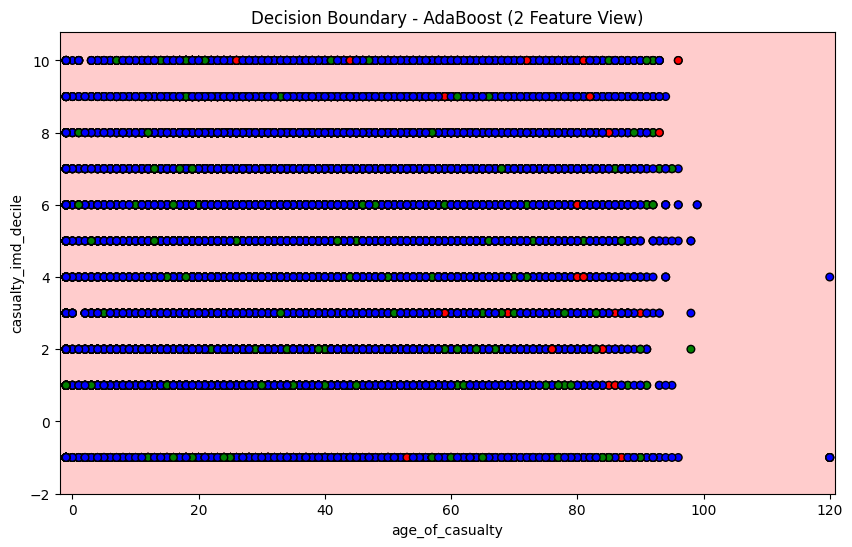

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.ensemble import AdaBoostClassifier

# Ambil dua fitur numerik
features = ['age_of_casualty', 'casualty_imd_decile']
X_vis = X[features].values
y_vis = y.values

# Latih model AdaBoost dengan best hyperparameters
ada = AdaBoostClassifier(
    n_estimators=162,
    learning_rate=0.890570482734688,
    random_state=42
)
ada.fit(X_vis, y_vis)

# Buat grid area prediksi
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.2),
    np.arange(y_min, y_max, 0.2)
)

# Prediksi grid
Z = ada.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Visualisasi boundary
plt.figure(figsize=(10, 6))
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ['red', 'green', 'blue']

plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, cmap=ListedColormap(cmap_bold), edgecolor='k', s=30)
plt.xlabel(features[0])
plt.ylabel(features[1])
plt.title("Decision Boundary - AdaBoost (2 Feature View)")
plt.show()


In [9]:
!pip install tensorflow

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# 1. One-hot encode target (karena deep learning pakai softmax)
y_dl = to_categorical(y)

# 2. Split (gunakan data sebelum SMOTE agar setara dengan model klasik)
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X, y_dl, test_size=0.2, stratify=y, random_state=42
)
model = Sequential()
model.add(Dense(128, activation='relu', input_dim=X.shape[1]))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(3, activation='softmax'))  # karena klasifikasi 3 kelas
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train_dl, y_train_dl,
                    validation_split=0.2,
                    epochs=50,
                    batch_size=32,
                    verbose=1)
# Evaluasi akurasi
test_loss, test_acc = model.evaluate(X_test_dl, y_test_dl, verbose=0)
print(f"\n✅ Deep Learning Test Accuracy: {test_acc:.4f}")

# Prediksi dan klasifikasi report
y_pred_dl = model.predict(X_test_dl)
y_pred_labels = tf.argmax(y_pred_dl, axis=1)
y_true_labels = tf.argmax(y_test_dl, axis=1)

print("\n=== Deep Learning Classification Report ===")
print(classification_report(y_true_labels, y_pred_labels))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 97.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 105.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 110.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.7 MB/s eta 0:00:00
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


933/933 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7927 - loss: 295.6215 - val_accuracy: 0.9003 - val_loss: 0.5292
Epoch 2/50
933/933 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8900 - loss: 1.1997 - val_accuracy: 0.9003 - val_loss: 0.3881
Epoch 3/50
933/933 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8911 - loss: 0.5103 - val_accuracy: 0.9003 - val_loss: 0.3705
Epoch 4/50
933/933 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8939 - loss: 0.4447 - val_accuracy: 0.9003 - val_loss: 0.3665
Epoch 5/50
933/933 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8964 - loss: 0.4228 - val_accuracy: 0.9003 - val_loss: 0.3654
Epoch 6/50
933/933 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8949 - loss: 0.4137 - val_accuracy: 0.9003 - val_loss: 0.3651
Epoch 7/50
933/933 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8969 - loss: 0.3778 - val_accuracy: 0.9003 - val_loss: 0.3651
Epoch 8/50
933/933 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8956 - loss: 0.3809 - val_accuracy: 0.9003 - va

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [12]:
import joblib
import pandas as pd

# === Simpan model ke file ===
joblib.dump(ada_best, "ada_model.pkl")
joblib.dump(lda_best, "lda_model.pkl")
joblib.dump(hist_best, "hist_model.pkl")

# === Load data tes ===
df_test = pd.read_csv("test_road_safety.csv")

# === Preprocessing tes (SAMAKAN dengan EDA skenario 1) ===
df_test.drop(columns=["status", "collision_year", "collision_reference", "lsoa_of_casualty", "enhanced_casualty_severity"], inplace=True)

# Imputasi nilai kosong
df_test["sex_of_casualty"].fillna(sex_mode, inplace=True)
df_test["pedestrian_road_maintenance_worker"].fillna(worker_mode, inplace=True)
df_test["casualty_home_area_type"].fillna(area_type_mode, inplace=True)

# Encoding sama seperti data latih
for col, le in label_encoders.items():
    test_vals = df_test[col].astype(str)

    # Cek apakah nilai sudah dikenal
    known_classes = set(le.classes_)
    test_vals_safe = test_vals.apply(lambda x: x if x in known_classes else None)

    # Update encoder agar bisa handle None
    le_classes = list(le.classes_)
    if None not in le_classes:
        le_classes.append(None)
        le.classes_ = np.array(le_classes)

    # Encode (yang None akan otomatis dapat nilai -1)
    df_test[col] = le.transform(test_vals_safe)


# === Prediksi dengan ketiga model ===
# Hapus target dari data test jika ikut terbaca
if 'casualty_severity' in df_test.columns:
    df_test = df_test.drop(columns=['casualty_severity'])

# Pastikan urutan dan nama kolom cocok dengan data training
df_test = df_test[X_train.columns]

# Prediksi
y_pred_ada_test = ada_best.predict(df_test)
y_pred_lda_test = lda_best.predict(df_test)
y_pred_hist_test = hist_best.predict(df_test)


# === Kembalikan label ke 1/2/3 jika sebelumnya dikurangi 1
y_pred_ada_test += 1
y_pred_lda_test += 1
y_pred_hist_test += 1

# === Simpan ke CSV
pd.DataFrame({"AdaBoost_Prediction": y_pred_ada_test}).to_csv("hasil_ada_skenario1.csv", index=False)
pd.DataFrame({"LDA_Prediction": y_pred_lda_test}).to_csv("hasil_lda_skenario1.csv", index=False)
pd.DataFrame({"HistGradientBoost_Prediction": y_pred_hist_test}).to_csv("hasil_hist_skenario1.csv", index=False)

print("✅ Model disimpan dan prediksi berhasil disimpan ke CSV.")


✅ Model disimpan dan prediksi berhasil disimpan ke CSV.


/tmp/ipython-input-12-505500189.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_test["sex_of_casualty"].fillna(sex_mode, inplace=True)
/tmp/ipython-input-12-505500189.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace